# Lab 16 — Positional Encoding and Sequence Geometry

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-16-positional-encoding.ipynb)

This lab accompanies **Chapter 16: Positional Encoding and Sequence Geometry** in *Mathematics of Natural Language Processing*.

Transformer attention compares token vectors by content. Without extra position information, the attention layer does not know whether a word occurred first, second, or last. This lab shows how order is injected into attention-based language models.

You will study:

1. why self-attention without position is permutation equivariant;
2. how learned absolute position embeddings work;
3. how sinusoidal positional encodings are built from sine and cosine features;
4. why sinusoidal dot products depend on relative offsets;
5. how position affects attention weights;
6. how relative position bias and rotary positional embeddings encode distance;
7. how to audit positional-encoding implementations.

Repository for the book: [https://github.com/wanghemath/Book-MathNLP](https://github.com/wanghemath/Book-MathNLP).

## 1. Mathematical background

A token sequence of length $T$ is represented by a matrix

$$
X \in \mathbb{R}^{T \times d},
$$

where row $x_t$ is the vector for the token at position $t$.

A single self-attention head computes

$$
Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V,
$$

$$
S = \frac{QK^T}{\sqrt{d_k}},
$$

$$
A = \operatorname{softmax}_{\text{row}}(S),
$$

$$
Y = AV.
$$

The row $A_{t,:}$ is a probability distribution over positions. It tells us which input positions token $t$ attends to.

The problem is that this formula only sees the rows of $X$ as vectors. If $X$ contains only token embeddings, attention is symmetric with respect to row permutations. To represent language, the model needs a way to represent order.

## 2. Setup

This lab uses only NumPy, pandas, and matplotlib. These are available in Google Colab by default.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7243)

## 3. A toy sentence where order matters

The two sentences below contain almost the same words but have different meanings:

- `the dog chased the cat`
- `the cat chased the dog`

A bag-of-words model has difficulty distinguishing them. A sequence model should not.

In [2]:
sent_a = "the dog chased the cat".split()
sent_b = "the cat chased the dog".split()

vocab_list = sorted(set(sent_a + sent_b + ["<pad>"]))
vocab = {w: i for i, w in enumerate(vocab_list)}
id_to_word = {i: w for w, i in vocab.items()}

ids_a = np.array([vocab[w] for w in sent_a])
ids_b = np.array([vocab[w] for w in sent_b])

print("Vocabulary:", vocab)
print("Sentence A ids:", ids_a)
print("Sentence B ids:", ids_b)

Vocabulary: {'<pad>': 0, 'cat': 1, 'chased': 2, 'dog': 3, 'the': 4}
Sentence A ids: [4 3 2 4 1]
Sentence B ids: [4 1 2 4 3]


## 4. Token embeddings alone

Let $E \in \mathbb{R}^{|V| \times d}$ be a token embedding matrix. Looking up token ids gives

$$
X_{\text{tok}} \in \mathbb{R}^{T \times d}.
$$

Here the same word receives the same vector wherever it appears.

In [3]:
T = len(sent_a)
d = 8
d_k = 8
V = len(vocab)

E = rng.normal(scale=0.4, size=(V, d))
X_a_tok = E[ids_a]
X_b_tok = E[ids_b]

print("E shape:", E.shape)
print("X_a_tok shape:", X_a_tok.shape)
print("Vector for 'dog' in sentence A at position 1:")
print(X_a_tok[1])
print("Vector for 'dog' in sentence B at position 4:")
print(X_b_tok[4])
print("Same vector?", np.allclose(X_a_tok[1], X_b_tok[4]))

E shape: (5, 8)
X_a_tok shape: (5, 8)
Vector for 'dog' in sentence A at position 1:
[ 0.4381 -0.7618 -0.0279  0.2342 -0.0178 -0.1269 -0.4845  0.55  ]
Vector for 'dog' in sentence B at position 4:
[ 0.4381 -0.7618 -0.0279  0.2342 -0.0178 -0.1269 -0.4845  0.55  ]
Same vector? True


## 5. Self-attention from scratch

We will use a small self-attention implementation throughout the lab.

For stability, row-wise softmax is computed after subtracting the row maximum.

In [4]:
def softmax_rows(S):
    S = np.asarray(S, dtype=float)
    S_shift = S - np.max(S, axis=1, keepdims=True)
    expS = np.exp(S_shift)
    return expS / expS.sum(axis=1, keepdims=True)


def self_attention(X, WQ, WK, WV, additive_bias=None, causal=False, return_details=False):
    Q = X @ WQ
    K = X @ WK
    Vv = X @ WV
    scores = (Q @ K.T) / math.sqrt(Q.shape[1])
    if additive_bias is not None:
        scores = scores + additive_bias
    if causal:
        mask = np.triu(np.ones_like(scores, dtype=bool), k=1)
        scores = scores.copy()
        scores[mask] = -1e9
    A = softmax_rows(scores)
    Y = A @ Vv
    if return_details:
        return Y, A, scores, Q, K, Vv
    return Y

WQ = rng.normal(scale=0.35, size=(d, d_k))
WK = rng.normal(scale=0.35, size=(d, d_k))
WV = rng.normal(scale=0.35, size=(d, d))

Y_a, A_a, S_a, *_ = self_attention(X_a_tok, WQ, WK, WV, return_details=True)

print("Attention matrix shape:", A_a.shape)
print(pd.DataFrame(A_a, index=sent_a, columns=sent_a))
print("Row sums:", A_a.sum(axis=1))

Attention matrix shape: (5, 5)
             the       dog    chased       the       cat
the     0.200905  0.195260  0.192345  0.200905  0.210584
dog     0.199919  0.178383  0.219474  0.199919  0.202306
chased  0.198616  0.197949  0.167100  0.198616  0.237720
the     0.200905  0.195260  0.192345  0.200905  0.210584
cat     0.195685  0.215379  0.192541  0.195685  0.200711
Row sums: [1. 1. 1. 1. 1.]


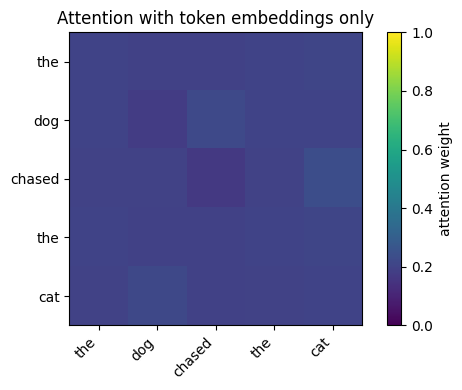

In [5]:
plt.figure(figsize=(5.5, 4))
plt.imshow(A_a, vmin=0, vmax=1)
plt.colorbar(label="attention weight")
plt.xticks(range(T), sent_a, rotation=45, ha="right")
plt.yticks(range(T), sent_a)
plt.title("Attention with token embeddings only")
plt.tight_layout()
plt.show()

## 6. Permutation equivariance without position

Let $P$ be a permutation matrix. If $X' = PX$, then self-attention without positional information satisfies

$$
\operatorname{Attn}(PX) = P\operatorname{Attn}(X).
$$

This means that if we reorder the input rows, the output rows reorder in the same way. This property is called **permutation equivariance**.

For language, this is not enough: the row index carries syntactic meaning.

In [6]:
perm = np.array([0, 4, 2, 3, 1])  # swap dog and cat positions while keeping length fixed
Pmat = np.eye(T)[perm]

X_perm = Pmat @ X_a_tok
Y_perm = self_attention(X_perm, WQ, WK, WV)
Y_expected = Pmat @ Y_a

print("Permutation:", perm)
print("||Attn(PX) - P Attn(X)||_F =", np.linalg.norm(Y_perm - Y_expected))

Permutation: [0 4 2 3 1]
||Attn(PX) - P Attn(X)||_F = 1.1775693440128312e-16


The numerical difference is essentially zero. The attention layer does not object when the input rows are permuted; it simply permutes its output rows.

## 7. Learned absolute position embeddings

One solution is to create a trainable position matrix

$$
P_{\text{learned}} \in \mathbb{R}^{T_{\max} \times d}.
$$

For a sequence of length $T$, we use the first $T$ rows and form

$$
X = X_{\text{tok}} + P_{\text{learned}}.
$$

In a real model, these position vectors are learned during training. In this lab, we simulate them with random vectors to study the geometry.

In [7]:
T_max = 12
P_learned = rng.normal(scale=0.25, size=(T_max, d))
X_a_abs = X_a_tok + P_learned[:T]
X_b_abs = X_b_tok + P_learned[:T]

print("Learned position matrix shape:", P_learned.shape)
print("Norms of token rows:", np.round(np.linalg.norm(X_a_tok, axis=1), 3))
print("Norms of position rows:", np.round(np.linalg.norm(P_learned[:T], axis=1), 3))

Learned position matrix shape: (12, 8)
Norms of token rows: [0.632 1.175 1.11  0.632 0.709]
Norms of position rows: [0.723 0.721 0.713 0.682 0.536]


Now compare the two sentences after absolute position vectors have been added. The word `dog` no longer has the same full input vector in positions 1 and 4, because the position part is different.

In [8]:
print("Dog in sentence A at position 1, token+position vector:")
print(X_a_abs[1])
print("Dog in sentence B at position 4, token+position vector:")
print(X_b_abs[4])
print("Same full vector?", np.allclose(X_a_abs[1], X_b_abs[4]))

Dog in sentence A at position 1, token+position vector:
[ 0.4223 -0.3113 -0.2309  0.125  -0.01   -0.2759 -0.2455  0.9784]
Dog in sentence B at position 4, token+position vector:
[ 0.339  -0.384   0.2438  0.3637  0.0185 -0.3077 -0.5004  0.6514]
Same full vector? False


## 8. Sinusoidal positional encoding

The original Transformer paper used fixed sinusoidal position vectors. For position $p$ and feature-pair index $j$,

$$
\operatorname{PE}(p,2j) = \sin\left(p / 10000^{2j/d}\right),
$$

$$
\operatorname{PE}(p,2j+1) = \cos\left(p / 10000^{2j/d}\right).
$$

The position vector is a finite set of Fourier-like features. Low-frequency coordinates change slowly with position; high-frequency coordinates change more quickly.

In [9]:
def sinusoidal_positional_encoding(T, d, base=10000.0):
    P = np.zeros((T, d), dtype=float)
    positions = np.arange(T)[:, None]
    div_terms = np.exp(np.arange(0, d, 2) * (-np.log(base) / d))
    P[:, 0::2] = np.sin(positions * div_terms)
    P[:, 1::2] = np.cos(positions * div_terms[:P[:, 1::2].shape[1]])
    return P

P_sin = sinusoidal_positional_encoding(T, d)
print(pd.DataFrame(P_sin, index=[f"pos {i}" for i in range(T)], columns=[f"coord {j}" for j in range(d)]))

        coord 0   coord 1   coord 2  ...  coord 5  coord 6   coord 7
pos 0  0.000000  1.000000  0.000000  ...  1.00000    0.000  1.000000
pos 1  0.841471  0.540302  0.099833  ...  0.99995    0.001  1.000000
pos 2  0.909297 -0.416147  0.198669  ...  0.99980    0.002  0.999998
pos 3  0.141120 -0.989992  0.295520  ...  0.99955    0.003  0.999996
pos 4 -0.756802 -0.653644  0.389418  ...  0.99920    0.004  0.999992

[5 rows x 8 columns]


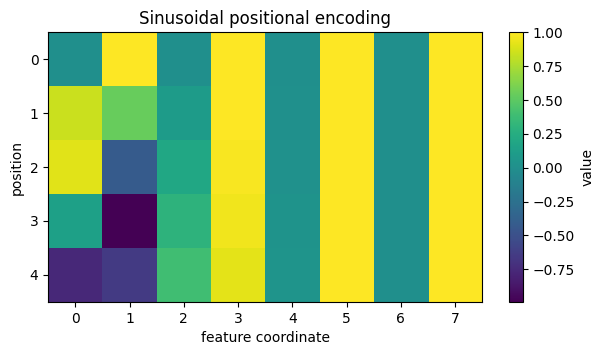

In [10]:
plt.figure(figsize=(7, 3.5))
plt.imshow(P_sin, aspect="auto")
plt.colorbar(label="value")
plt.xlabel("feature coordinate")
plt.ylabel("position")
plt.title("Sinusoidal positional encoding")
plt.show()

### Check the shape

A common mistake is to generate a position matrix with shape $d \times T$ instead of $T \times d$. For Transformer inputs, each row is a position, so the correct shape is

$$
P \in \mathbb{R}^{T \times d}.
$$

In [11]:
assert P_sin.shape == X_a_tok.shape
X_a_sin = X_a_tok + P_sin
print("X_a_tok shape:", X_a_tok.shape)
print("P_sin shape:", P_sin.shape)
print("X_a_sin shape:", X_a_sin.shape)

X_a_tok shape: (5, 8)
P_sin shape: (5, 8)
X_a_sin shape: (5, 8)


## 9. Similarity geometry of sinusoidal positions

For sinusoidal encodings, the dot product between two position vectors depends strongly on their offset $p-q$.

The reason is the trigonometric identity

$$
\sin(a)\sin(b)+\cos(a)\cos(b)=\cos(a-b).
$$

Each sine-cosine pair contributes a cosine of a relative difference. Thus positional similarity is connected to relative distance.

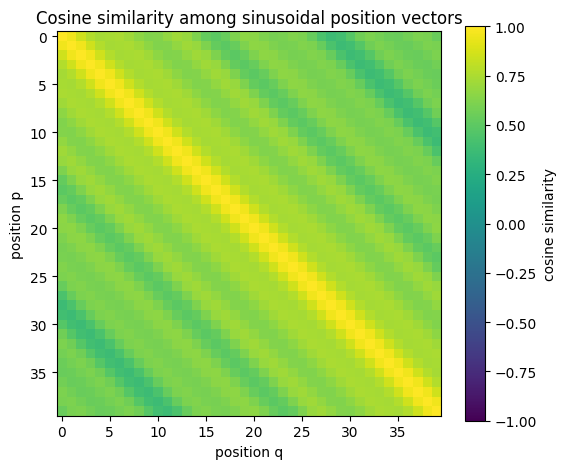

In [12]:
T_big = 40
d_big = 32
P_big = sinusoidal_positional_encoding(T_big, d_big)
G = P_big @ P_big.T
G_norm = G / np.sqrt(np.diag(G)[:, None] * np.diag(G)[None, :])

plt.figure(figsize=(5.8, 4.8))
plt.imshow(G_norm, vmin=-1, vmax=1)
plt.colorbar(label="cosine similarity")
plt.xlabel("position q")
plt.ylabel("position p")
plt.title("Cosine similarity among sinusoidal position vectors")
plt.tight_layout()
plt.show()

    offset  mean cosine similarity           std
0        0                1.000000  0.000000e+00
1        1                0.957103  1.686550e-16
2        2                0.858134  2.138592e-16
3        3                0.767025  2.428265e-16
4        4                0.728844  1.125537e-16
5        5                0.736086  1.465687e-16
6        6                0.743234  1.996950e-16
7        7                0.714183  1.237500e-16
8        8                0.657629  1.331111e-16
9        9                0.617597  2.409383e-16
10      10                0.628683  1.671491e-16
11      11                0.678785  1.166235e-16
12      12                0.715533  1.006225e-16
13      13                0.692094  1.208658e-16
14      14                0.610994  9.737300e-17
15      15                0.525379  9.678700e-17


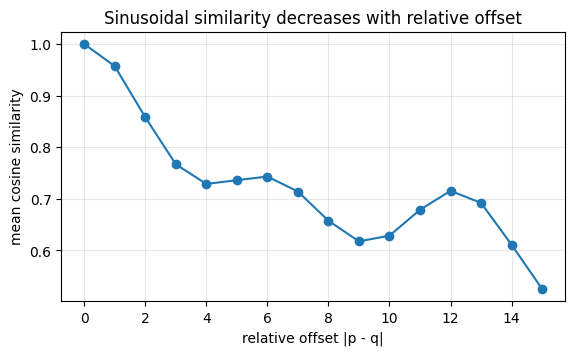

In [13]:
max_offset = 15
offset_rows = []
for offset in range(max_offset + 1):
    vals = []
    for p in range(T_big - offset):
        vals.append(G_norm[p, p + offset])
    offset_rows.append({"offset": offset, "mean cosine similarity": float(np.mean(vals)), "std": float(np.std(vals))})

df_offsets = pd.DataFrame(offset_rows)
print(df_offsets)

plt.figure(figsize=(6.5, 3.5))
plt.plot(df_offsets["offset"], df_offsets["mean cosine similarity"], marker="o")
plt.xlabel("relative offset |p - q|")
plt.ylabel("mean cosine similarity")
plt.title("Sinusoidal similarity decreases with relative offset")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Position changes attention weights

Let us compare attention on the same sentence with and without sinusoidal position vectors.

In [14]:
Y_tok, A_tok, S_tok, *_ = self_attention(X_a_tok, WQ, WK, WV, return_details=True)
Y_sin, A_sin, S_sin, *_ = self_attention(X_a_sin, WQ, WK, WV, return_details=True)

print("Frobenius norm of attention difference:", np.linalg.norm(A_sin - A_tok))
print("Attention with token embeddings only:")
print(pd.DataFrame(A_tok, index=sent_a, columns=sent_a))
print("\nAttention with token + sinusoidal position:")
print(pd.DataFrame(A_sin, index=sent_a, columns=sent_a))

Frobenius norm of attention difference: 0.4367669386244687
Attention with token embeddings only:
             the       dog    chased       the       cat
the     0.200905  0.195260  0.192345  0.200905  0.210584
dog     0.199919  0.178383  0.219474  0.199919  0.202306
chased  0.198616  0.197949  0.167100  0.198616  0.237720
the     0.200905  0.195260  0.192345  0.200905  0.210584
cat     0.195685  0.215379  0.192541  0.195685  0.200711

Attention with token + sinusoidal position:
             the       dog    chased       the       cat
the     0.194491  0.085665  0.139687  0.258467  0.321690
dog     0.162051  0.056614  0.133081  0.258484  0.389770
chased  0.162240  0.057821  0.108346  0.236582  0.435011
the     0.246940  0.088936  0.187539  0.221495  0.255090
cat     0.287065  0.131178  0.220450  0.194295  0.167012


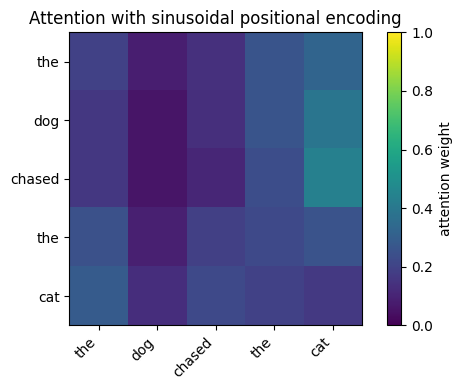

In [15]:
plt.figure(figsize=(5.5, 4))
plt.imshow(A_sin, vmin=0, vmax=1)
plt.colorbar(label="attention weight")
plt.xticks(range(T), sent_a, rotation=45, ha="right")
plt.yticks(range(T), sent_a)
plt.title("Attention with sinusoidal positional encoding")
plt.tight_layout()
plt.show()

## 11. Scaling token embeddings and position embeddings

Many Transformer implementations scale token embeddings by $\sqrt{d}$ before adding position vectors:

$$
X = \sqrt{d}X_{\text{tok}} + P.
$$

This changes the relative size of content information and position information. If token vectors are too small, position may dominate. If position vectors are too small, the model may struggle to distinguish order.

In [16]:
def row_norm_summary(name, M):
    norms = np.linalg.norm(M, axis=1)
    return {"matrix": name, "mean row norm": norms.mean(), "min": norms.min(), "max": norms.max()}

summaries = [
    row_norm_summary("token only", X_a_tok),
    row_norm_summary("sqrt(d) token", math.sqrt(d) * X_a_tok),
    row_norm_summary("sinusoidal position", P_sin),
    row_norm_summary("token + position", X_a_tok + P_sin),
    row_norm_summary("sqrt(d) token + position", math.sqrt(d) * X_a_tok + P_sin),
]
print(pd.DataFrame(summaries))

                     matrix  mean row norm       min       max
0                token only       0.851707  0.632120  1.175369
1             sqrt(d) token       2.408992  1.787906  3.324446
2       sinusoidal position       2.000000  2.000000  2.000000
3          token + position       2.202439  1.773005  2.569217
4  sqrt(d) token + position       3.171736  2.044293  4.301264


In [17]:
scales = [0.25, 0.5, 1.0, math.sqrt(d), 2 * math.sqrt(d)]
rows = []
for scale in scales:
    X_scaled = scale * X_a_tok + P_sin
    _, A_scaled, _, *_ = self_attention(X_scaled, WQ, WK, WV, return_details=True)
    rows.append({
        "token scale": scale,
        "attention change from token-only": np.linalg.norm(A_scaled - A_tok),
        "attention entropy mean": float(-(A_scaled * np.log(A_scaled + 1e-12)).sum(axis=1).mean())
    })
print(pd.DataFrame(rows))

   token scale  attention change from token-only  attention entropy mean
0     0.250000                          0.323538                1.549368
1     0.500000                          0.357461                1.536108
2     1.000000                          0.436767                1.499440
3     2.828427                          0.807913                1.271365
4     5.656854                          1.125918                0.981218


## 12. Relative position bias

Another way to encode order is to add a bias to the attention scores based on relative distance:

$$
S_{ij} = \frac{q_i^T k_j}{\sqrt{d_k}} + b(i-j).
$$

A simple distance-decay bias is

$$
b(i-j) = -\lambda |i-j|.
$$

This encourages attention to nearby positions.

In [18]:
def distance_decay_bias(T, lam=0.5):
    idx = np.arange(T)
    return -lam * np.abs(idx[:, None] - idx[None, :])

B_decay = distance_decay_bias(T, lam=0.7)
Y_bias, A_bias, S_bias, *_ = self_attention(X_a_tok, WQ, WK, WV, additive_bias=B_decay, return_details=True)

print("Distance-decay bias:")
print(pd.DataFrame(B_decay, index=sent_a, columns=sent_a))
print("\nAttention with distance-decay bias:")
print(pd.DataFrame(A_bias, index=sent_a, columns=sent_a))

Distance-decay bias:
        the  dog  chased  the  cat
the    -0.0 -0.7    -1.4 -2.1 -2.8
dog    -0.7 -0.0    -0.7 -1.4 -2.1
chased -1.4 -0.7    -0.0 -0.7 -1.4
the    -2.1 -1.4    -0.7 -0.0 -0.7
cat    -2.8 -2.1    -1.4 -0.7 -0.0

Attention with distance-decay bias:
             the       dog    chased       the       cat
the     0.524957  0.253361  0.123937  0.064284  0.033461
dog     0.215482  0.387183  0.236559  0.107005  0.053771
chased  0.103849  0.208424  0.354305  0.209126  0.124295
the     0.051931  0.101638  0.201618  0.424078  0.220736
cat     0.031018  0.068748  0.123762  0.253296  0.523176


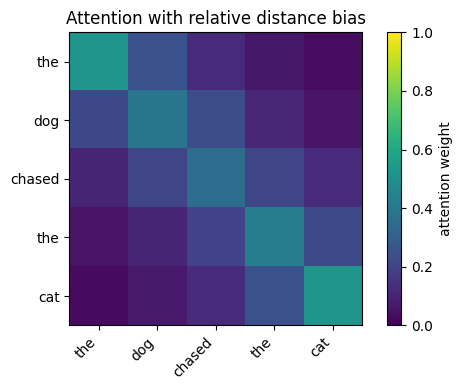

In [19]:
plt.figure(figsize=(5.5, 4))
plt.imshow(A_bias, vmin=0, vmax=1)
plt.colorbar(label="attention weight")
plt.xticks(range(T), sent_a, rotation=45, ha="right")
plt.yticks(range(T), sent_a)
plt.title("Attention with relative distance bias")
plt.tight_layout()
plt.show()

## 13. Causal masking plus relative bias

In autoregressive language modeling, position $i$ may attend only to positions $j \leq i$. A causal mask sets future scores to a very negative number before softmax.

Relative position bias can be combined with causal masking.

In [20]:
_, A_causal, _, *_ = self_attention(X_a_tok, WQ, WK, WV, causal=True, return_details=True)
_, A_causal_bias, _, *_ = self_attention(X_a_tok, WQ, WK, WV, additive_bias=B_decay, causal=True, return_details=True)

print("Causal attention without distance bias:")
print(pd.DataFrame(A_causal, index=sent_a, columns=sent_a))
print("\nCausal attention with distance bias:")
print(pd.DataFrame(A_causal_bias, index=sent_a, columns=sent_a))

Causal attention without distance bias:
             the       dog    chased       the       cat
the     1.000000  0.000000  0.000000  0.000000  0.000000
dog     0.528464  0.471536  0.000000  0.000000  0.000000
chased  0.352365  0.351182  0.296452  0.000000  0.000000
the     0.254499  0.247347  0.243655  0.254499  0.000000
cat     0.195685  0.215379  0.192541  0.195685  0.200711

Causal attention with distance bias:
             the       dog    chased       the       cat
the     1.000000  0.000000  0.000000  0.000000  0.000000
dog     0.357548  0.642452  0.000000  0.000000  0.000000
chased  0.155794  0.312678  0.531527  0.000000  0.000000
the     0.066641  0.130428  0.258728  0.544203  0.000000
cat     0.031018  0.068748  0.123762  0.253296  0.523176


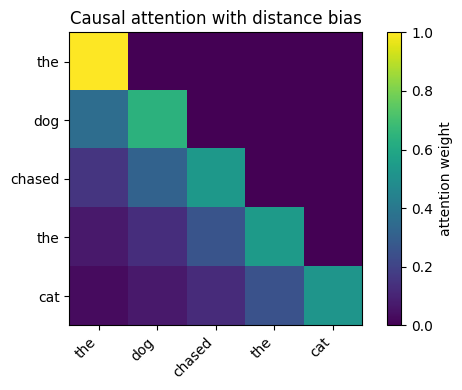

In [21]:
plt.figure(figsize=(5.5, 4))
plt.imshow(A_causal_bias, vmin=0, vmax=1)
plt.colorbar(label="attention weight")
plt.xticks(range(T), sent_a, rotation=45, ha="right")
plt.yticks(range(T), sent_a)
plt.title("Causal attention with distance bias")
plt.tight_layout()
plt.show()

## 14. Rotary positional embeddings: the basic idea

Rotary positional embeddings, often called RoPE, encode position by rotating query and key coordinates. For a two-dimensional pair $(u_0,u_1)$ and angle $\theta$, define

$$
R_{\theta}
\begin{bmatrix}
u_0 \\ u_1
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
u_0 \\ u_1
\end{bmatrix}.
$$

RoPE applies different rotation frequencies to different coordinate pairs. Position $p$ uses angles $p\omega_j$.

The key property is that dot products between rotated queries and keys depend on relative position offsets.

In [22]:
def apply_rope(X, base=10000.0):
    """Apply a simple RoPE transform to X with shape (T, d), where d is even."""
    T, d = X.shape
    if d % 2 != 0:
        raise ValueError("This simple RoPE implementation requires even d.")
    positions = np.arange(T)[:, None]
    freqs = np.exp(np.arange(0, d, 2) * (-np.log(base) / d))[None, :]
    angles = positions * freqs
    cos = np.cos(angles)
    sin = np.sin(angles)
    X_even = X[:, 0::2]
    X_odd = X[:, 1::2]
    Y = np.zeros_like(X)
    Y[:, 0::2] = X_even * cos - X_odd * sin
    Y[:, 1::2] = X_even * sin + X_odd * cos
    return Y

# Use identity-like projections here to isolate the geometric effect.
Q_plain = X_a_tok.copy()
K_plain = X_a_tok.copy()
Q_rope = apply_rope(Q_plain)
K_rope = apply_rope(K_plain)

S_plain = Q_plain @ K_plain.T / math.sqrt(d)
S_rope = Q_rope @ K_rope.T / math.sqrt(d)

print("Plain dot-product scores:")
print(pd.DataFrame(S_plain, index=sent_a, columns=sent_a))
print("\nRoPE dot-product scores:")
print(pd.DataFrame(S_rope, index=sent_a, columns=sent_a))
print("\nScore difference norm:", np.linalg.norm(S_rope - S_plain))

Plain dot-product scores:
             the       dog    chased       the       cat
the     0.141271  0.017246  0.157789  0.141271 -0.111660
dog     0.017246  0.488431  0.040195  0.017246  0.008306
chased  0.157789  0.040195  0.435353  0.157789 -0.120254
the     0.141271  0.017246  0.157789  0.141271 -0.111660
cat    -0.111660  0.008306 -0.120254 -0.111660  0.177854

RoPE dot-product scores:
             the       dog    chased       the       cat
the     0.141271 -0.010635  0.157751  0.125937 -0.099155
dog    -0.010635  0.488431  0.114421  0.058702 -0.005692
chased  0.157751  0.114421  0.435353  0.142227 -0.110252
the     0.125937  0.058702  0.142227  0.141271 -0.110285
cat    -0.099155 -0.005692 -0.110252 -0.110285  0.177854

Score difference norm: 0.13369338932192698


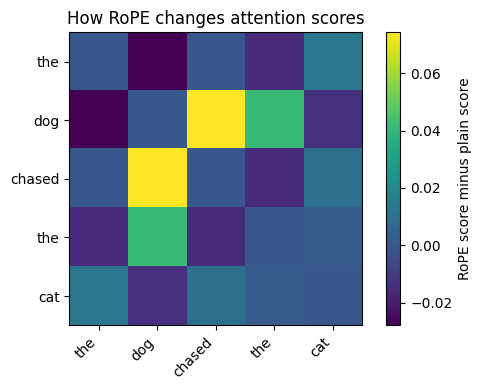

In [23]:
plt.figure(figsize=(5.5, 4))
plt.imshow(S_rope - S_plain)
plt.colorbar(label="RoPE score minus plain score")
plt.xticks(range(T), sent_a, rotation=45, ha="right")
plt.yticks(range(T), sent_a)
plt.title("How RoPE changes attention scores")
plt.tight_layout()
plt.show()

## 15. RoPE preserves vector norms

Each coordinate pair is rotated by an orthogonal $2 \times 2$ matrix. Therefore RoPE preserves the norm of each row:

$$
\|R_{\theta}u\|_2 = \|u\|_2.
$$

This is a useful implementation check.

In [24]:
plain_norms = np.linalg.norm(Q_plain, axis=1)
rope_norms = np.linalg.norm(Q_rope, axis=1)
print(pd.DataFrame({"token": sent_a, "plain norm": plain_norms, "RoPE norm": rope_norms, "difference": rope_norms - plain_norms}))
print("Maximum absolute norm difference:", np.max(np.abs(plain_norms - rope_norms)))

    token  plain norm  RoPE norm    difference
0     the    0.632120   0.632120  0.000000e+00
1     dog    1.175369   1.175369  0.000000e+00
2  chased    1.109669   1.109669 -2.220446e-16
3     the    0.632120   0.632120  0.000000e+00
4     cat    0.709259   0.709259  0.000000e+00
Maximum absolute norm difference: 2.220446049250313e-16


## 16. Feature-design viewpoint

Position methods can be compared as feature-design choices:

| Method | What is added or changed? | Strength | Limitation |
|---|---|---|---|
| Learned absolute position | Learn $p_t$ and use $x_t+p_t$ | Flexible | tied to training lengths unless handled carefully |
| Sinusoidal absolute position | Fixed sine/cosine features | extrapolates more naturally | fixed feature basis |
| Relative position bias | Add $b(i-j)$ to scores | directly models distance | may not encode full token-position interaction |
| RoPE | rotate queries and keys by position | relative geometry inside dot products | implementation shape mistakes are common |

The right method depends on architecture, training data, target context length, and extrapolation needs.

## 17. Implementation audit checklist

When debugging positional encodings, ask:

1. Is the position matrix shaped $T \times d$?
2. Are token and position matrices added with compatible shapes?
3. Are positions restarted correctly for each sequence in a batch?
4. Are padding tokens masked so that position does not make them meaningful?
5. Is the causal mask applied before softmax?
6. For RoPE, are rotations applied to both queries and keys, not values?
7. For RoPE, is the model dimension or head dimension even where pairwise rotations are used?
8. Are dtype and device choices consistent in deep-learning frameworks?

## 18. Exercises

### Exercise 1: Shape check

Change $T$ and $d$ in the sinusoidal encoding example. Verify that $P$ always has shape $T \times d$.

### Exercise 2: Position similarity

Compute the cosine similarity between positions $0$ and $k$ for $k=1,2,\ldots,30$. Plot the result for $d=8$, $d=32$, and $d=128$. What changes as $d$ increases?

### Exercise 3: Position strength

Replace $X = X_{\text{tok}} + P$ by

$$
X = X_{\text{tok}} + \alpha P.
$$

Try $\alpha=0,0.1,1,5$. How does the attention matrix change?

### Exercise 4: Relative bias

Modify the distance-decay bias to prefer tokens exactly two positions away:

$$
b(i-j) = -\left(|i-j|-2\right)^2.
$$

Visualize the resulting attention weights.

### Exercise 5: RoPE norm preservation

Generate ten random matrices $X \in \mathbb{R}^{T \times d}$ and verify numerically that RoPE preserves every row norm.

## 19. Mini-project: compare four position strategies

Build a small experiment comparing four attention score matrices for the same sentence:

1. no positional information;
2. learned absolute position vectors;
3. sinusoidal position vectors;
4. relative distance-decay bias.

For each method, report:

- the attention heatmap;
- the average attention entropy;
- whether nearby tokens receive more attention;
- one paragraph explaining what mathematical feature the method adds.

A strong answer connects the visualization to the formulas, not only to code output.

In [25]:
def attention_entropy(A):
    return -(A * np.log(A + 1e-12)).sum(axis=1)

methods = {}
methods["no position"] = self_attention(X_a_tok, WQ, WK, WV, return_details=True)[1]
methods["learned absolute"] = self_attention(X_a_abs, WQ, WK, WV, return_details=True)[1]
methods["sinusoidal absolute"] = self_attention(X_a_sin, WQ, WK, WV, return_details=True)[1]
methods["relative bias"] = self_attention(X_a_tok, WQ, WK, WV, additive_bias=B_decay, return_details=True)[1]

summary = []
for name, A in methods.items():
    nearby_mass = 0.0
    count = 0
    for i in range(T):
        for j in range(T):
            if abs(i - j) <= 1:
                nearby_mass += A[i, j]
                count += 1
    summary.append({
        "method": name,
        "mean entropy": attention_entropy(A).mean(),
        "mean nearby attention weight": nearby_mass / count,
        "max weight": A.max()
    })

print(pd.DataFrame(summary))

                method  mean entropy  mean nearby attention weight  max weight
0          no position      1.607405                      0.196757    0.237720
1     learned absolute      1.606231                      0.196543    0.235779
2  sinusoidal absolute      1.499440                      0.158468    0.435011
3        relative bias      1.365966                      0.308638    0.524957


## 20. AI-assisted learning prompts

Use an AI assistant as a tutor, not as a replacement for your own reasoning.

1. Ask it to explain why self-attention without positional encoding is permutation equivariant. Then reproduce the proof using matrices.
2. Give it your sinusoidal encoding code and ask it to identify possible shape errors.
3. Ask it to compare learned absolute positions, sinusoidal positions, relative position bias, and RoPE in a table.
4. Ask it to generate a new sentence pair where the same words in a different order change the meaning. Test your position methods on that pair.

Always verify the answer by checking formulas, dimensions, and numerical experiments.

## 21. Summary

In this lab, you learned that:

- self-attention without position is permutation equivariant;
- token identity and token position are different sources of information;
- learned absolute position embeddings add trainable row-dependent vectors;
- sinusoidal encodings use sine and cosine features at multiple frequencies;
- sinusoidal dot products encode relative offsets through trigonometric identities;
- relative position bias changes attention scores directly;
- RoPE encodes position by rotating query and key coordinates;
- positional methods should be audited by shape, norm, masking, and score behavior.

The next lab moves from positional features to autoregressive language modeling, where causal prediction and next-token likelihood become central.